# Maternal Health Risk Prediction

## Ensemble Learning

### Objective
This notebook combines multiple machine learning models using Ensemble Learning techniques to improve prediction performance and robustness.

#### Ensemble Methods Used
- Hard Voting Classifier
- Soft Voting Classifier
- Stacking Classifier

#### Base Models
- Random Forest
- XGBoost
- Support Vector Classifier
- K-Nearest Neighbors

#### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Classification Report

#### Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import (
    VotingClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression

from sklearn.base import clone

import os
import pickle

#### Load Dataset

In [2]:
data = pd.read_csv("../Dataset/Maternal Health Risk Data Set.csv")

data.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


#### Data Information

In [3]:
print("="*60)
print("Dataset Shape :", data.shape)
print("="*60)

data.info()

Dataset Shape : (1014, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


#### Features and Target

In [4]:
X = data.drop("RiskLevel", axis=1)
y = data["RiskLevel"]

print("Features :", X.shape)
print("Target :", y.shape)

Features : (1014, 6)
Target : (1014,)


#### Train Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (811, 6)
Testing Samples : (203, 6)


#### Load Trained Models

In [6]:
print("="*60)
print("Loading Trained Models...")
print("="*60)

with open("../Model/random_forest.pkl", "rb") as f:
    rf_model = pickle.load(f)

with open("../Model/xgboost.pkl", "rb") as f:
    xgb_model = pickle.load(f)

with open("../Model/svc.pkl", "rb") as f:
    svc_model = pickle.load(f)

with open("../Model/knn.pkl", "rb") as f:
    knn_model = pickle.load(f)

print("✓ Random Forest Loaded")
print("✓ XGBoost Loaded")
print("✓ SVC Loaded")
print("✓ KNN Loaded")

Loading Trained Models...
✓ Random Forest Loaded
✓ XGBoost Loaded
✓ SVC Loaded
✓ KNN Loaded


#### Hard Voting Classifier / Create Hard Voting

In [7]:
hard_voting = VotingClassifier(

    estimators=[
        ('RandomForest', clone(rf_model)),
        ('XGBoost', clone(xgb_model)),
        ('SVC', clone(svc_model)),
        ('KNN', clone(knn_model))
    ],

    voting='hard'

)

print("Hard Voting Classifier Created Successfully.")

Hard Voting Classifier Created Successfully.


#### Train Hard Voting

In [8]:
print("Training Hard Voting Classifier...")

hard_voting.fit(X_train, y_train)

print("Training Completed.")

Training Hard Voting Classifier...
Training Completed.


#### Hard Voting Evaluation

In [9]:
hard_pred = hard_voting.predict(X_test)

hard_accuracy = accuracy_score(y_test, hard_pred)
hard_precision = precision_score(y_test, hard_pred, average="weighted")
hard_recall = recall_score(y_test, hard_pred, average="weighted")
hard_f1 = f1_score(y_test, hard_pred, average="weighted")

print("="*60)
print("Hard Voting Performance")
print("="*60)

print(f"Accuracy  : {hard_accuracy:.4f}")
print(f"Precision : {hard_precision:.4f}")
print(f"Recall    : {hard_recall:.4f}")
print(f"F1 Score  : {hard_f1:.4f}")

Hard Voting Performance
Accuracy  : 0.8670
Precision : 0.8673
Recall    : 0.8670
F1 Score  : 0.8666


#### Confusion Matrix

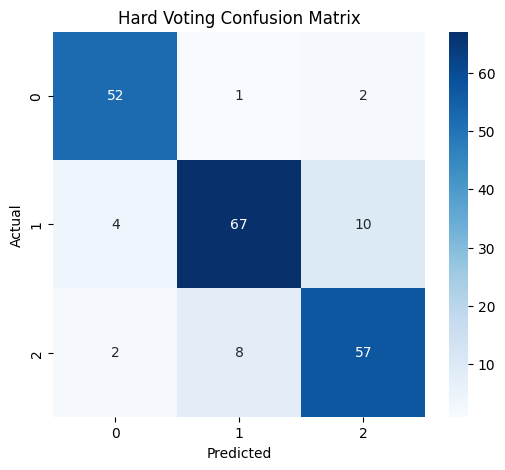

In [10]:
cm = confusion_matrix(y_test, hard_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Hard Voting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### Classification Report

In [11]:
print("="*60)
print("Classification Report")
print("="*60)

print(classification_report(y_test, hard_pred))

Classification Report
              precision    recall  f1-score   support

   high risk       0.90      0.95      0.92        55
    low risk       0.88      0.83      0.85        81
    mid risk       0.83      0.85      0.84        67

    accuracy                           0.87       203
   macro avg       0.87      0.87      0.87       203
weighted avg       0.87      0.87      0.87       203



#### Soft Voting Classifier

In [12]:
soft_voting = VotingClassifier(

    estimators=[
        ('RandomForest', clone(rf_model)),
        ('XGBoost', clone(xgb_model)),
        ('SVC', clone(svc_model)),
        ('KNN', clone(knn_model))
    ],

    voting='soft'

)

print("Soft Voting Classifier Created Successfully.")

Soft Voting Classifier Created Successfully.


#### Train Soft Voting

In [13]:
print("Training Soft Voting Classifier...")

soft_voting.fit(X_train, y_train)

print("Training Completed.")

Training Soft Voting Classifier...
Training Completed.


#### Soft Voting Evaluation

In [14]:
soft_pred = soft_voting.predict(X_test)

soft_accuracy = accuracy_score(y_test, soft_pred)
soft_precision = precision_score(
    y_test,
    soft_pred,
    average="weighted"
)
soft_recall = recall_score(
    y_test,
    soft_pred,
    average="weighted"
)
soft_f1 = f1_score(
    y_test,
    soft_pred,
    average="weighted"
)

print("="*60)
print("Soft Voting Performance")
print("="*60)

print(f"Accuracy  : {soft_accuracy:.4f}")
print(f"Precision : {soft_precision:.4f}")
print(f"Recall    : {soft_recall:.4f}")
print(f"F1 Score  : {soft_f1:.4f}")

Soft Voting Performance
Accuracy  : 0.8473
Precision : 0.8464
Recall    : 0.8473
F1 Score  : 0.8467


#### Confusion Matrix

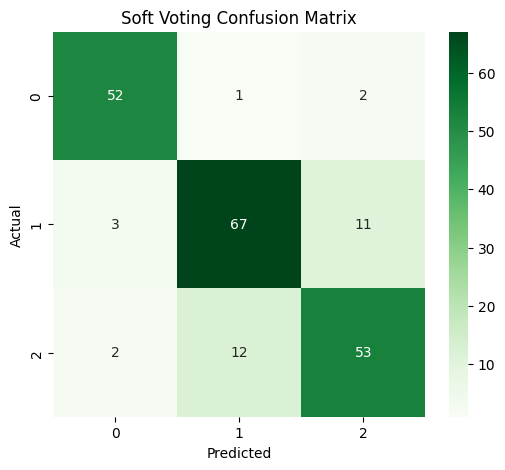

In [15]:
cm = confusion_matrix(y_test, soft_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Soft Voting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### Classification Report

In [16]:
print("="*60)
print("Soft Voting Classification Report")
print("="*60)

print(classification_report(y_test, soft_pred))

Soft Voting Classification Report
              precision    recall  f1-score   support

   high risk       0.91      0.95      0.93        55
    low risk       0.84      0.83      0.83        81
    mid risk       0.80      0.79      0.80        67

    accuracy                           0.85       203
   macro avg       0.85      0.85      0.85       203
weighted avg       0.85      0.85      0.85       203



#### Soft Voting Summary

In [17]:
print("="*60)
print("Soft Voting Completed Successfully")
print("="*60)

print(f"Accuracy  : {soft_accuracy:.4f}")
print(f"Precision : {soft_precision:.4f}")
print(f"Recall    : {soft_recall:.4f}")
print(f"F1 Score  : {soft_f1:.4f}")

Soft Voting Completed Successfully
Accuracy  : 0.8473
Precision : 0.8464
Recall    : 0.8473
F1 Score  : 0.8467


#### Stacking Classifier

In [18]:
stacking_model = StackingClassifier(

    estimators=[

        ("RandomForest", clone(rf_model)),
        ("XGBoost", clone(xgb_model)),
        ("SVC", clone(svc_model)),
        ("KNN", clone(knn_model))

    ],

    final_estimator=LogisticRegression(max_iter=1000),

    cv=5,

    n_jobs=-1

)

print("Stacking Classifier Created Successfully.")

Stacking Classifier Created Successfully.


#### Train Stacking Model

In [19]:
print("="*60)
print("Training Stacking Classifier...")
print("="*60)

stacking_model.fit(X_train, y_train)

print("\nTraining Completed Successfully.")

Training Stacking Classifier...

Training Completed Successfully.


#### Evaluate Stacking Model

In [20]:
stack_pred = stacking_model.predict(X_test)

stack_accuracy = accuracy_score(y_test, stack_pred)

stack_precision = precision_score(
    y_test,
    stack_pred,
    average="weighted"
)

stack_recall = recall_score(
    y_test,
    stack_pred,
    average="weighted"
)

stack_f1 = f1_score(
    y_test,
    stack_pred,
    average="weighted"
)

print("="*60)
print("Stacking Classifier Performance")
print("="*60)

print(f"Accuracy  : {stack_accuracy:.4f}")
print(f"Precision : {stack_precision:.4f}")
print(f"Recall    : {stack_recall:.4f}")
print(f"F1 Score  : {stack_f1:.4f}")

Stacking Classifier Performance
Accuracy  : 0.8621
Precision : 0.8637
Recall    : 0.8621
F1 Score  : 0.8627


#### Confusion Matrix

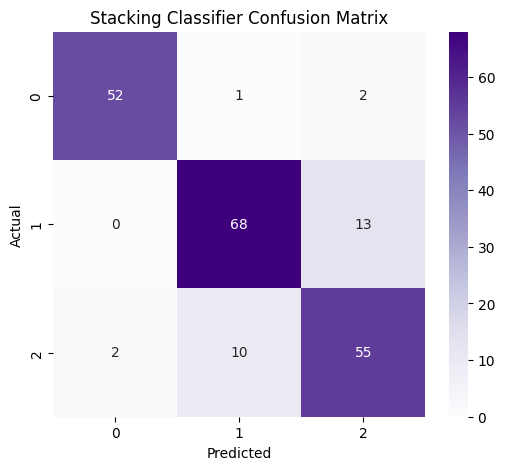

In [21]:
cm = confusion_matrix(y_test, stack_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Stacking Classifier Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

#### Classification Report

In [22]:
print("="*60)
print("Stacking Classification Report")
print("="*60)

print(classification_report(
    y_test,
    stack_pred
))

Stacking Classification Report
              precision    recall  f1-score   support

   high risk       0.96      0.95      0.95        55
    low risk       0.86      0.84      0.85        81
    mid risk       0.79      0.82      0.80        67

    accuracy                           0.86       203
   macro avg       0.87      0.87      0.87       203
weighted avg       0.86      0.86      0.86       203



#### Stacking Summary

In [23]:
print("="*60)
print("Stacking Model Completed Successfully")
print("="*60)

print(f"Accuracy  : {stack_accuracy:.4f}")
print(f"Precision : {stack_precision:.4f}")
print(f"Recall    : {stack_recall:.4f}")
print(f"F1 Score  : {stack_f1:.4f}")

Stacking Model Completed Successfully
Accuracy  : 0.8621
Precision : 0.8637
Recall    : 0.8621
F1 Score  : 0.8627


#### Ensemble Performance Comparison

In [24]:
comparison = pd.DataFrame({

    "Model":[
        "Hard Voting",
        "Soft Voting",
        "Stacking"
    ],

    "Accuracy":[
        hard_accuracy,
        soft_accuracy,
        stack_accuracy
    ],

    "Precision":[
        hard_precision,
        soft_precision,
        stack_precision
    ],

    "Recall":[
        hard_recall,
        soft_recall,
        stack_recall
    ],

    "F1 Score":[
        hard_f1,
        soft_f1,
        stack_f1
    ]

})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison.reset_index(
    drop=True,
    inplace=True
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Hard Voting,0.866995,0.867321,0.866995,0.866576
1,Stacking,0.862069,0.863681,0.862069,0.862673
2,Soft Voting,0.847291,0.846384,0.847291,0.846729


#### Ensemble Model Comparison

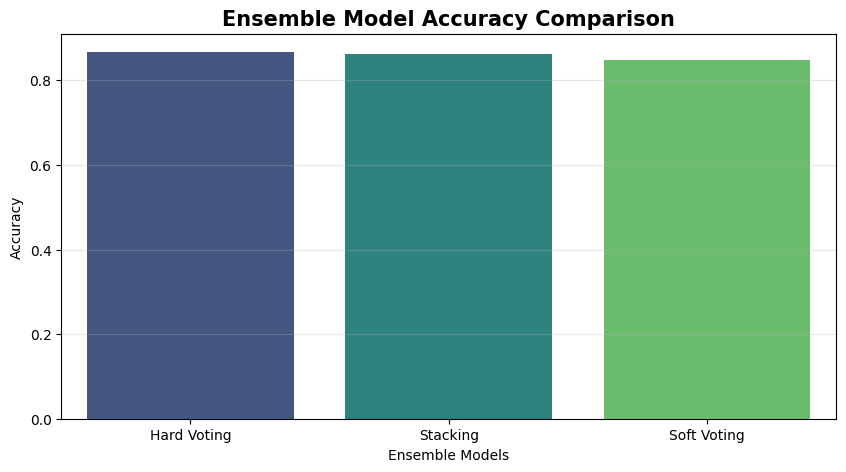

In [25]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title(
    "Ensemble Model Accuracy Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Ensemble Models")

plt.ylabel("Accuracy")

plt.grid(axis="y", alpha=0.3)

plt.show()

#### Select Best Ensemble Model

In [26]:
models = {
    "Hard Voting": hard_voting,
    "Soft Voting": soft_voting,
    "Stacking": stacking_model
}

best_name = comparison.iloc[0]["Model"]

best_model = models[best_name]

print("="*60)
print("Best Ensemble Model")
print("="*60)

print("Model :", best_name)

print("Accuracy :", round(comparison.iloc[0]["Accuracy"]*100,2), "%")

Best Ensemble Model
Model : Hard Voting
Accuracy : 86.7 %


#### Save Best Ensemble Model

In [27]:
import os
import pickle

os.makedirs("../Model", exist_ok=True)

MODEL_PATH = "../Model/best_model_stack.pkl"

with open(MODEL_PATH, "wb") as f:

    pickle.dump(best_model, f)

print("="*60)

print("Best Ensemble Model Saved Successfully")

print("Location :", MODEL_PATH)

Best Ensemble Model Saved Successfully
Location : ../Model/best_model_stack.pkl


#### Final Summary

In [28]:
summary = pd.DataFrame({

    "Best Ensemble Model":[best_name],

    "Accuracy":[round(comparison.iloc[0]["Accuracy"]*100,2)],

    "Precision":[round(comparison.iloc[0]["Precision"]*100,2)],

    "Recall":[round(comparison.iloc[0]["Recall"]*100,2)],

    "F1 Score":[round(comparison.iloc[0]["F1 Score"]*100,2)]

})

summary

,Best Ensemble Model,Accuracy,Precision,Recall,F1 Score
0,Hard Voting,86.7,86.73,86.7,86.66


#### Conclusion

### Ensemble Learning Completed Successfully

##### Ensemble Techniques Implemented

- Hard Voting Classifier
- Soft Voting Classifier
- Stacking Classifier

##### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Classification Report

##### Best Ensemble Model

The best performing ensemble model has been selected automatically and saved for future deployment.

**Saved Model**

`../Model/best_model_stack.pkl`